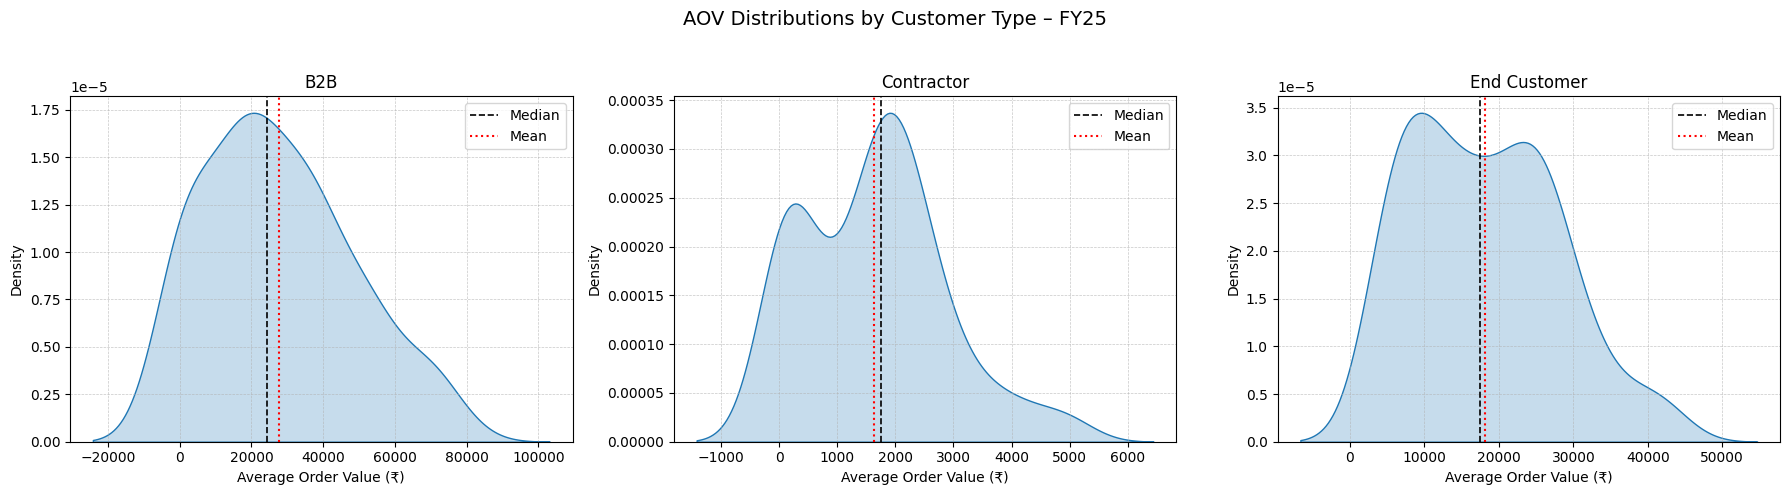

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

# Data
b2b = np.clip(np.random.normal(29160, 26733, 105), 240, 244213)
contractor = np.clip(np.random.normal(1462, 1320, 105), 19, 5000)
end_customer = np.clip(np.random.normal(16680, 11381, 105), 5010, 49982)

segments = {
    'B2B': b2b,
    'Contractor': contractor,
    'End Customer': end_customer
}

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, (label, data) in zip(axs, segments.items()):
    sns.kdeplot(data, fill=True, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("Average Order Value (₹)")
    ax.set_ylabel("Density")
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    # Median and Mean
    median_val = np.median(data)
    mean_val = np.mean(data)

    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.2, label='Median')
    ax.axvline(mean_val, color='red', linestyle=':', linewidth=1.5, label='Mean')

    ax.legend()

plt.suptitle("AOV Distributions by Customer Type – FY25", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [2]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Buyer Segment', y='AOV', data=df_violin, inner='quartile', scale='width')
plt.title('Violin Plot of Average Order Value by Buyer Segment')
plt.ylabel('Average Order Value (₹)')
plt.xlabel('Buyer Segment')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


NameError: name 'df_violin' is not defined

<Figure size 1000x600 with 0 Axes>

/tmp/ipython-input-3-3209044265.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.94])


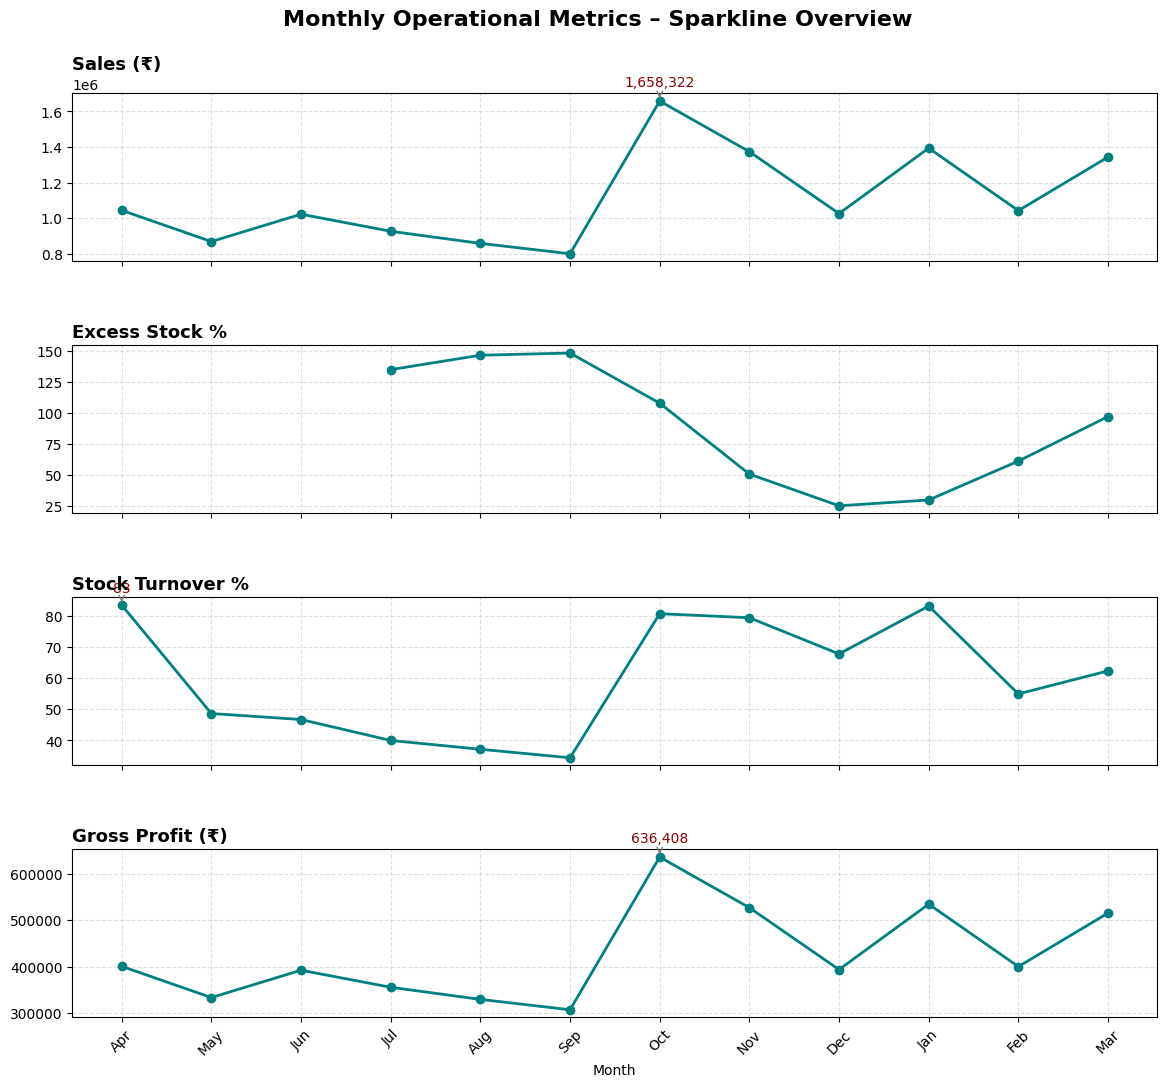

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data
months = ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar']
sales = [1043927, 868210, 1021975, 926080, 857940, 799553, 1658322, 1373745, 1025580, 1393484, 1042187, 1343400]
excess_stock = [np.nan, np.nan, np.nan, 135.10, 146.76, 148.51, 108.05, 50.82, 25.24, 29.90, 61.31, 97.25]
stock_turnover = [83.35, 48.62, 46.70, 39.99, 37.17, 34.45, 80.58, 79.29, 67.70, 83.03, 54.90, 62.26]
gross_profit = [400624.20, 333189.91, 392199.76, 355398.47, 329248.62, 306841.65, 636408.42, 527197.30, 393583.24, 534772.47, 399956.45, 515551.90]

# Metrics to plot
metrics = {
    'Sales (₹)': sales,
    'Excess Stock %': excess_stock,
    'Stock Turnover %': stock_turnover,
    'Gross Profit (₹)': gross_profit
}

# Plot
fig, axes = plt.subplots(len(metrics), 1, figsize=(14, 12), sharex=True, gridspec_kw={'hspace': 0.5})
for ax, (label, data) in zip(axes, metrics.items()):
    ax.plot(months, data, marker='o', color='teal', linewidth=2)
    ax.set_title(label, fontsize=13, weight='bold', loc='left')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)

    # Add max-point annotation (only if no missing values)
    if not any(pd.isnull(data)):
        max_idx = np.argmax(data)
        max_val = data[max_idx]
        ax.annotate(f'{max_val:,.0f}',
                    xy=(months[max_idx], max_val),
                    xytext=(months[max_idx], max_val + 0.05 * max_val),
                    ha='center', fontsize=10, color='darkred',
                    arrowprops=dict(arrowstyle='->', color='gray'))

# Add overall title
plt.suptitle("Monthly Operational Metrics – Sparkline Overview", fontsize=16, weight='bold', y=0.95)
plt.xlabel("Month")
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show();
